# <b>1 <span style='color:#4285f4'>|</span> Importing libraries</b>
- **For ML Models**: Tensorflow, keras
- **For Data Manipulation**: numpy, pandas, sklearn
- **For Data Visualization**: matplotlib, seaborn,plotly

In [56]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFE
warnings.filterwarnings('ignore')

# <b>2 <span style='color:#4285f4'>|</span> Reading the Dataset</b>

In [57]:
df = pd.read_csv('vitals_datareal.csv')


In [58]:
# df types
df.dtypes

Skin_temp     float64
Heart_rate      int64
SPO2            int64
Target         object
dtype: object

# <b>3 <span style='color:#4285f4'>|</span> EDA </b>

In [59]:
df.head()

,Skin_temp,Heart_rate,SPO2,Target
0,35.1,98,99,Normal
1,35.2,107,96,Normal
2,35.7,81,100,Normal
3,35.2,120,96,Normal
4,35.2,85,100,Normal


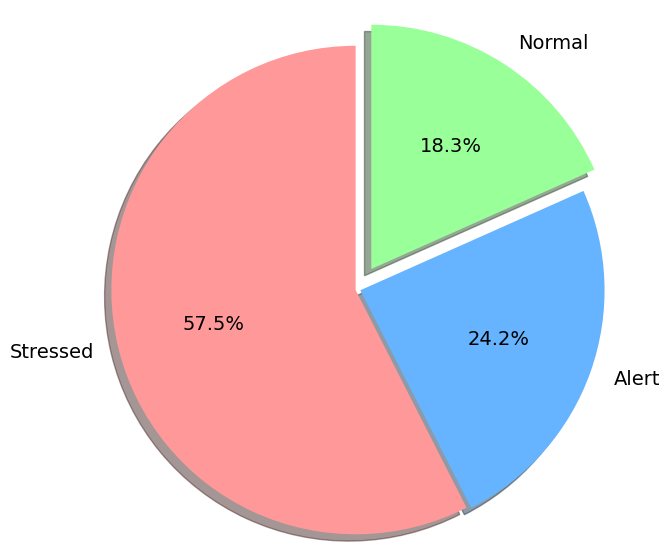

In [60]:
#  make a piechart of the Target column

# Pie chart, where the slices will be ordered and plotted counter-clockwise:
labels = df['Target'].value_counts().index
sizes = df['Target'].value_counts().values
explode = (0.01, 0.01, 0.1)  # only "explode" the 2nd slice (i.e. 'Hogs')
fig1, ax1 = plt.subplots(figsize=(7, 7))
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 14}, colors=['#ff9999', '#66b3ff', '#99ff99'])
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()



# <b>3 <span style='color:#4285f4'>|</span> Preprocessing </b>

In [61]:
import datetime

df = df.rename(columns={'Row': 'Timestamp'})

In [62]:
# make histogram for timestamp with Heart_rate column

fig = px.histogram(df, x="SPO2", y="Heart_rate", color="Target", marginal="rug",
                     hover_data=df.columns)
fig.show()


In [63]:
# columns names in the dataset
df.columns


Index(['Skin_temp', 'Heart_rate', 'SPO2', 'Target'], dtype='object')

In [64]:
# plot Heart_rate with Target column
fig = px.scatter(df, x="Heart_rate", y="Target", color="Target",
                    hover_data=['Heart_rate'])
fig.show()

# plot SPO2 with Target column
fig = px.scatter(df, x="SPO2", y="Target", color="Target",
                    hover_data=['SPO2'])
fig.show()

# plot Temperature with Target column
fig = px.scatter(df, x="Skin_temp", y="Target", color="Target",
                    hover_data=['Skin_temp'])

fig.show()

# change plot type to box plot
fig = px.box(df, x="Target", y="Heart_rate", points="all")
fig.show()


# change plot type to box plot
fig = px.box(df, x="Target", y="SPO2", points="all", color="Target")
fig.show()

# change plot type to violin plot
fig = px.violin(df, y="Heart_rate", x="Target", color="Target",
                     box=True, points="all", hover_data=df.columns) 
fig.show()

# change plot type to violin plot
fig = px.violin(df, y="SPO2", x="Target", color="Target",
                        box=True, points="all", hover_data=df.columns)  
fig.show()

# change plot type to violin plot
fig = px.violin(df, y="Skin_temp", x="Target", color="Target",
                        box=True, points="all", hover_data=df.columns)  
fig.show()


##### This plot shows the relationship between heart_rate and taget variable. We can see that the heart_rate is higher in the alert state than the stressed and normal states.

## Are there any missing values?

In [65]:
print(df.isnull().values.any())


False


### If there's missing values, replace with average between neighbouring values:

In [66]:
# Check for null values
if df.isnull().values.any():
    # Replace null values with average of neighboring values
    df['Timestamp'] = df['Timestamp'].fillna((df['Timestamp'].shift() + df['Timestamp'].shift(-1)) / 2)


<Axes: >

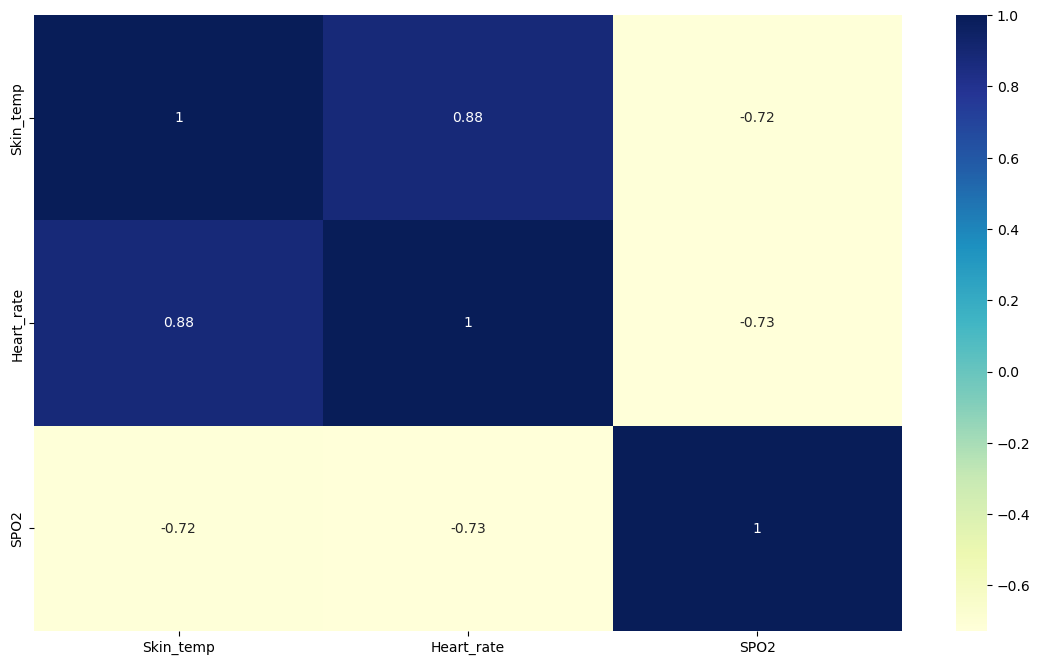

In [67]:
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(), annot=True, cmap="YlGnBu")

# <b>3 <span style='color:#4285f4'>|</span> OUTLIERS </b>

In [68]:
# Delete outliers:
# Delete all heart rate values above 250
df = df.drop(df[df['Heart_rate']>250].index)
# Delete all heart rate values below 40
df = df.drop(df[df['Heart_rate']<20].index)
# Delete all SPO2 values BELOW 75
df = df.drop(df[df['SPO2']<75].index)
# Delete all SPO2 values ABOVE 100
df = df.drop(df[df['SPO2']>100].index)
# Delete all temperature values BELOW 25
df = df.drop(df[df['Skin_temp']<25].index)
# Delete all temperature values ABOVE 50
df = df.drop(df[df['Skin_temp']>50].index)


## Hot encoding for categorical data

In [69]:
encoded_data = pd.get_dummies(df, columns=['Target'])


# <b>3-2 <span style='color:#4285f4'>|</span> Encoding data </b>

In [70]:
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])

Hot

In [71]:
df.dtypes

Skin_temp     float64
Heart_rate      int64
SPO2            int64
Target          int32
dtype: object

In [72]:
df

,Skin_temp,Heart_rate,SPO2,Target
0,35.1,98,99,1
1,35.2,107,96,1
2,35.7,81,100,1
3,35.2,120,96,1
4,35.2,85,100,1
...,...,...,...,...
1795,36.8,148,90,2
1796,36.7,146,90,2
1797,37.0,121,94,2
1798,37.1,122,92,2


# <b>4 <span style='color:#4285f4'>|</span> Splitting data </b>

In [73]:
X = df.drop(['Target'], axis=1)
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# <b>5 <span style='color:#4285f4'>|</span> Scaling the data </b>

In [74]:
# use robust scaler to scale the data
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# <b>6 <span style='color:#4285f4'>|</span> ML Models </b>

## Table of models and their scores

In [75]:
from prettytable import PrettyTable
x = PrettyTable()
x.field_names = ["Model", "Train Score", "Test Score", "R2 Score", "Mean Absolute Error", "Mean Squared Error"]

# <b>6.1 <span style='color:#4285f4'>|</span> Lasso regression </b>

In [76]:
lasso = Lasso()
lasso.fit(X_train, y_train)
lasso_train_score = lasso.score(X_train, y_train)
lasso_test_score = lasso.score(X_test, y_test)
lasso_r2_score = r2_score(y_test, lasso.predict(X_test))
lasso_mae = mean_absolute_error(y_test, lasso.predict(X_test))
lasso_mse = mean_squared_error(y_test, lasso.predict(X_test))
x.add_row(["Lasso Regression", lasso_train_score, lasso_test_score, lasso_r2_score, lasso_mae, lasso_mse])

print(x)


+------------------+-------------+-----------------------+-----------------------+---------------------+--------------------+
|      Model       | Train Score |       Test Score      |        R2 Score       | Mean Absolute Error | Mean Squared Error |
+------------------+-------------+-----------------------+-----------------------+---------------------+--------------------+
| Lasso Regression |     0.0     | -0.018688095683049744 | -0.018688095683049744 |  0.7574074074074074 | 0.6729629629629629 |
+------------------+-------------+-----------------------+-----------------------+---------------------+--------------------+


# <b>6.2 <span style='color:#4285f4'>|</span>  Linear Regression </b>

In [77]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_train_score = lr.score(X_train, y_train)
lr_test_score = lr.score(X_test, y_test)
lr_r2_score = r2_score(y_test, lr.predict(X_test))
lr_mae = mean_absolute_error(y_test, lr.predict(X_test))
lr_mse = mean_squared_error(y_test, lr.predict(X_test))
x.add_row(["Linear Regression", lr_train_score, lr_test_score, lr_r2_score, lr_mae, lr_mse])

print(x)


+-------------------+--------------------+-----------------------+-----------------------+---------------------+---------------------+
|       Model       |    Train Score     |       Test Score      |        R2 Score       | Mean Absolute Error |  Mean Squared Error |
+-------------------+--------------------+-----------------------+-----------------------+---------------------+---------------------+
|  Lasso Regression |        0.0         | -0.018688095683049744 | -0.018688095683049744 |  0.7574074074074074 |  0.6729629629629629 |
| Linear Regression | 0.4611594267947843 |   0.4255418494799693  |   0.4255418494799693  |  0.5598606232995674 | 0.37949698313983754 |
+-------------------+--------------------+-----------------------+-----------------------+---------------------+---------------------+


# <b>6.3 <span style='color:#4285f4'>|</span> Ridge regression </b>

In [78]:
ridge = Ridge()
ridge.fit(X_train, y_train)
ridge_train_score = ridge.score(X_train, y_train)
ridge_test_score = ridge.score(X_test, y_test)
ridge_r2_score = r2_score(y_test, ridge.predict(X_test))
ridge_mae = mean_absolute_error(y_test, ridge.predict(X_test))
ridge_mse = mean_squared_error(y_test, ridge.predict(X_test))
x.add_row(["Ridge Regression", ridge_train_score, ridge_test_score, ridge_r2_score, ridge_mae, ridge_mse])

print(x)

+-------------------+---------------------+-----------------------+-----------------------+---------------------+---------------------+
|       Model       |     Train Score     |       Test Score      |        R2 Score       | Mean Absolute Error |  Mean Squared Error |
+-------------------+---------------------+-----------------------+-----------------------+---------------------+---------------------+
|  Lasso Regression |         0.0         | -0.018688095683049744 | -0.018688095683049744 |  0.7574074074074074 |  0.6729629629629629 |
| Linear Regression |  0.4611594267947843 |   0.4255418494799693  |   0.4255418494799693  |  0.5598606232995674 | 0.37949698313983754 |
|  Ridge Regression | 0.46115815394813686 |   0.4254656389701781  |   0.4254656389701781  |  0.5601523210821198 | 0.37954732911982436 |
+-------------------+---------------------+-----------------------+-----------------------+---------------------+---------------------+


# <b>6.4 <span style='color:#4285f4'>|</span> Ada Boost regressor </b>

In [79]:
abr = AdaBoostRegressor()
abr.fit(X_train, y_train)
abr_train_score = abr.score(X_train, y_train)
abr_test_score = abr.score(X_test, y_test)
abr_r2_score = r2_score(y_test, abr.predict(X_test))
abr_mae = mean_absolute_error(y_test, abr.predict(X_test))
abr_mse = mean_squared_error(y_test, abr.predict(X_test))
x.add_row(["Ada Boost Regressor", abr_train_score, abr_test_score, abr_r2_score, abr_mae, abr_mse])

print(x)

+---------------------+---------------------+-----------------------+-----------------------+---------------------+---------------------+
|        Model        |     Train Score     |       Test Score      |        R2 Score       | Mean Absolute Error |  Mean Squared Error |
+---------------------+---------------------+-----------------------+-----------------------+---------------------+---------------------+
|   Lasso Regression  |         0.0         | -0.018688095683049744 | -0.018688095683049744 |  0.7574074074074074 |  0.6729629629629629 |
|  Linear Regression  |  0.4611594267947843 |   0.4255418494799693  |   0.4255418494799693  |  0.5598606232995674 | 0.37949698313983754 |
|   Ridge Regression  | 0.46115815394813686 |   0.4254656389701781  |   0.4254656389701781  |  0.5601523210821198 | 0.37954732911982436 |
| Ada Boost Regressor |         1.0         |          1.0          |          1.0          |         0.0         |         0.0         |
+---------------------+-----------

# <b>6.5 <span style='color:#4285f4'>|</span> Gradient Boosting Regressor </b>

In [80]:
gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)
gbr_train_score = gbr.score(X_train, y_train)
gbr_test_score = gbr.score(X_test, y_test)
gbr_r2_score = r2_score(y_test, gbr.predict(X_test))
gbr_mae = mean_absolute_error(y_test, gbr.predict(X_test))
gbr_mse = mean_squared_error(y_test, gbr.predict(X_test))
x.add_row(["Gradient Boosting Regressor", gbr_train_score, gbr_test_score, gbr_r2_score, gbr_mae, gbr_mse])

print(x)


+-----------------------------+---------------------+-----------------------+-----------------------+------------------------+-----------------------+
|            Model            |     Train Score     |       Test Score      |        R2 Score       |  Mean Absolute Error   |   Mean Squared Error  |
+-----------------------------+---------------------+-----------------------+-----------------------+------------------------+-----------------------+
|       Lasso Regression      |         0.0         | -0.018688095683049744 | -0.018688095683049744 |   0.7574074074074074   |   0.6729629629629629  |
|      Linear Regression      |  0.4611594267947843 |   0.4255418494799693  |   0.4255418494799693  |   0.5598606232995674   |  0.37949698313983754  |
|       Ridge Regression      | 0.46115815394813686 |   0.4254656389701781  |   0.4254656389701781  |   0.5601523210821198   |  0.37954732911982436  |
|     Ada Boost Regressor     |         1.0         |          1.0          |          1.0    

# <b>6.6 <span style='color:#4285f4'>|</span> Random Forest Regressor </b>

In [81]:
rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)
rfr_train_score = rfr.score(X_train, y_train)
rfr_test_score = rfr.score(X_test, y_test)
rfr_r2_score = r2_score(y_test, rfr.predict(X_test))
rfr_mae = mean_absolute_error(y_test, rfr.predict(X_test))
rfr_mse = mean_squared_error(y_test, rfr.predict(X_test))
x.add_row(["Random Forest Regressor", rfr_train_score, rfr_test_score, rfr_r2_score, rfr_mae, rfr_mse])

print(x)


+-----------------------------+---------------------+-----------------------+-----------------------+------------------------+-----------------------+
|            Model            |     Train Score     |       Test Score      |        R2 Score       |  Mean Absolute Error   |   Mean Squared Error  |
+-----------------------------+---------------------+-----------------------+-----------------------+------------------------+-----------------------+
|       Lasso Regression      |         0.0         | -0.018688095683049744 | -0.018688095683049744 |   0.7574074074074074   |   0.6729629629629629  |
|      Linear Regression      |  0.4611594267947843 |   0.4255418494799693  |   0.4255418494799693  |   0.5598606232995674   |  0.37949698313983754  |
|       Ridge Regression      | 0.46115815394813686 |   0.4254656389701781  |   0.4254656389701781  |   0.5601523210821198   |  0.37954732911982436  |
|     Ada Boost Regressor     |         1.0         |          1.0          |          1.0    

# <b>6.7 <span style='color:#4285f4'>|</span> Decision Tree Regressor </b>

In [82]:
dtr = DecisionTreeRegressor()
dtr.fit(X_train, y_train)
dtr_train_score = dtr.score(X_train, y_train)
dtr_test_score = dtr.score(X_test, y_test)
dtr_r2_score = r2_score(y_test, dtr.predict(X_test))
dtr_mae = mean_absolute_error(y_test, dtr.predict(X_test))
dtr_mse = mean_squared_error(y_test, dtr.predict(X_test))
x.add_row(["Decision Tree Regressor", dtr_train_score, dtr_test_score, dtr_r2_score, dtr_mae, dtr_mse])

print(x)

+-----------------------------+---------------------+-----------------------+-----------------------+------------------------+-----------------------+
|            Model            |     Train Score     |       Test Score      |        R2 Score       |  Mean Absolute Error   |   Mean Squared Error  |
+-----------------------------+---------------------+-----------------------+-----------------------+------------------------+-----------------------+
|       Lasso Regression      |         0.0         | -0.018688095683049744 | -0.018688095683049744 |   0.7574074074074074   |   0.6729629629629629  |
|      Linear Regression      |  0.4611594267947843 |   0.4255418494799693  |   0.4255418494799693  |   0.5598606232995674   |  0.37949698313983754  |
|       Ridge Regression      | 0.46115815394813686 |   0.4254656389701781  |   0.4254656389701781  |   0.5601523210821198   |  0.37954732911982436  |
|     Ada Boost Regressor     |         1.0         |          1.0          |          1.0    

# <b>6.8 <span style='color:#4285f4'>|</span>  XG Boost Regressor </b>

In [83]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
xgb_train_score = xgb.score(X_train, y_train)
xgb_test_score = xgb.score(X_test, y_test)
xgb_r2_score = r2_score(y_test, xgb.predict(X_test))
xgb_mae = mean_absolute_error(y_test, xgb.predict(X_test))
xgb_mse = mean_squared_error(y_test, xgb.predict(X_test))
x.add_row(["XG Boost Regressor", xgb_train_score, xgb_test_score, xgb_r2_score, xgb_mae, xgb_mse])


print(x)



+-----------------------------+---------------------+-----------------------+-----------------------+------------------------+------------------------+
|            Model            |     Train Score     |       Test Score      |        R2 Score       |  Mean Absolute Error   |   Mean Squared Error   |
+-----------------------------+---------------------+-----------------------+-----------------------+------------------------+------------------------+
|       Lasso Regression      |         0.0         | -0.018688095683049744 | -0.018688095683049744 |   0.7574074074074074   |   0.6729629629629629   |
|      Linear Regression      |  0.4611594267947843 |   0.4255418494799693  |   0.4255418494799693  |   0.5598606232995674   |  0.37949698313983754   |
|       Ridge Regression      | 0.46115815394813686 |   0.4254656389701781  |   0.4254656389701781  |   0.5601523210821198   |  0.37954732911982436   |
|     Ada Boost Regressor     |         1.0         |          1.0          |          1

# <b>6.9 <span style='color:#4285f4'>|</span>  Support vector regressor </b>

In [84]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(X_train, y_train)
svr_train_score = svr.score(X_train, y_train)
svr_test_score = svr.score(X_test, y_test)
svr_r2_score = r2_score(y_test, svr.predict(X_test))
svr_mae = mean_absolute_error(y_test, svr.predict(X_test))
svr_mse = mean_squared_error(y_test, svr.predict(X_test))
x.add_row(["Support Vector Regressor", svr_train_score, svr_test_score, svr_r2_score, svr_mae, svr_mse])

print(x)


+-----------------------------+---------------------+-----------------------+-----------------------+------------------------+------------------------+
|            Model            |     Train Score     |       Test Score      |        R2 Score       |  Mean Absolute Error   |   Mean Squared Error   |
+-----------------------------+---------------------+-----------------------+-----------------------+------------------------+------------------------+
|       Lasso Regression      |         0.0         | -0.018688095683049744 | -0.018688095683049744 |   0.7574074074074074   |   0.6729629629629629   |
|      Linear Regression      |  0.4611594267947843 |   0.4255418494799693  |   0.4255418494799693  |   0.5598606232995674   |  0.37949698313983754   |
|       Ridge Regression      | 0.46115815394813686 |   0.4254656389701781  |   0.4254656389701781  |   0.5601523210821198   |  0.37954732911982436   |
|     Ada Boost Regressor     |         1.0         |          1.0          |          1

# <b>7 <span style='color:#4285f4'>|</span>  Comparison in graph </b>

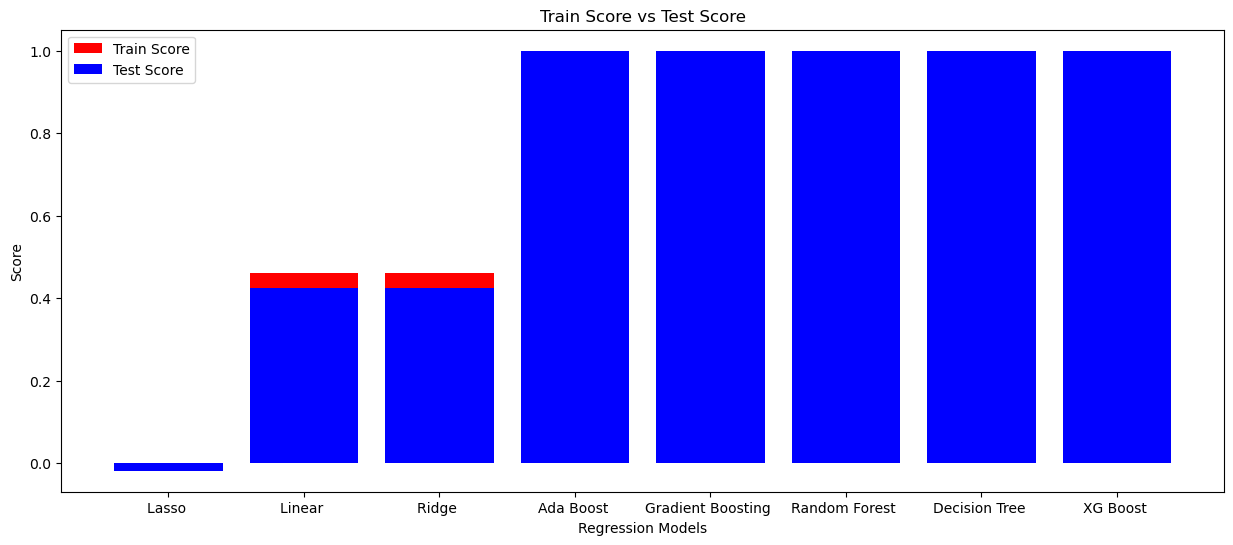

In [85]:
plt.figure(figsize=(15, 6))
plt.bar(x=["Lasso ", "Linear ", "Ridge ", "Ada Boost ", "Gradient Boosting ", "Random Forest ", "Decision Tree ", "XG Boost "], height=[lasso_train_score, lr_train_score, ridge_train_score, abr_train_score, gbr_train_score, rfr_train_score, dtr_train_score, xgb_train_score], color="red", label="Train Score")
plt.bar(x=["Lasso ", "Linear ", "Ridge ", "Ada Boost ", "Gradient Boosting ", "Random Forest ", "Decision Tree ", "XG Boost "], height=[lasso_test_score, lr_test_score, ridge_test_score, abr_test_score, gbr_test_score, rfr_test_score, dtr_test_score, xgb_test_score], color="blue", label="Test Score")
plt.legend()
plt.title("Train Score vs Test Score")
plt.xlabel("Regression Models")
plt.ylabel("Score")
plt.show()


In [86]:
# make an ROC curve 
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

# calculate AUC
auc = roc_auc_score(y_test, xgb.predict(X_test))
print('AUC: %.3f' % auc)

# calculate roc curve
fpr, tpr, thresholds = roc_curve(y_test, xgb.predict(X_test))

# plot no skill
plt.plot([0, 1], [0, 1], linestyle='--')

# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# show the plot
plt.show()


ValueError: multi_class must be in ('ovo', 'ovr')